In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import metrics
from sklearn.datasets import load_iris

In [3]:
data = load_iris()
df = pd.DataFrame(data=data.data,columns=data.feature_names)
df['target'] = data.target ==0

In [4]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,True
1,4.9,3.0,1.4,0.2,True
2,4.7,3.2,1.3,0.2,True
3,4.6,3.1,1.5,0.2,True
4,5.0,3.6,1.4,0.2,True


In [5]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
X = df.drop(columns=['target'])
y = df['target']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

In [8]:
gini_tree = DecisionTreeClassifier(random_state=42,criterion='gini')
ig_tree = DecisionTreeClassifier(random_state=42,criterion='entropy')
gini_tree.fit(X_train,y_train)
ig_tree.fit(X_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [9]:
y_pred_gini = gini_tree.predict(X_test)
y_pred_ig = ig_tree.predict(X_test)

In [10]:
print(metrics.classification_report(y_test,y_pred_gini))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00        23
        True       1.00      1.00      1.00         7

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [11]:
print(metrics.classification_report(y_test,y_pred_ig))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00        23
        True       1.00      1.00      1.00         7

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [12]:
cm1 = metrics.confusion_matrix(y_test,y_pred_gini)

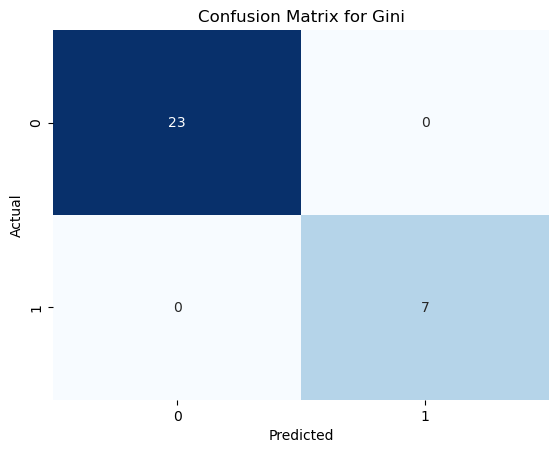

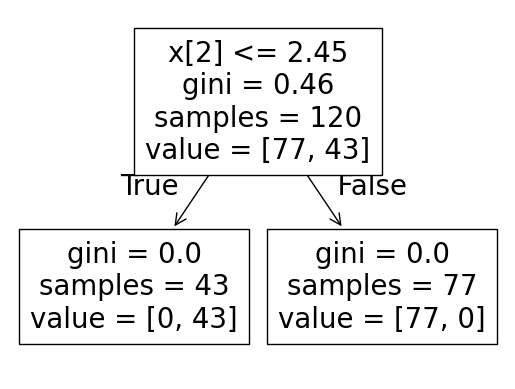

In [13]:
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix for Gini")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
plot_tree(gini_tree)
plt.show()

In [14]:
cm2 = metrics.confusion_matrix(y_test,y_pred_ig)

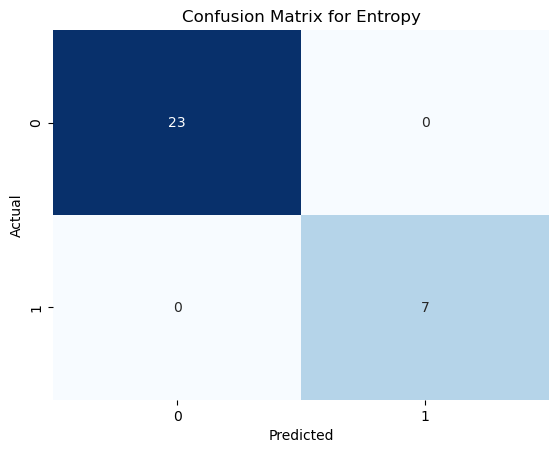

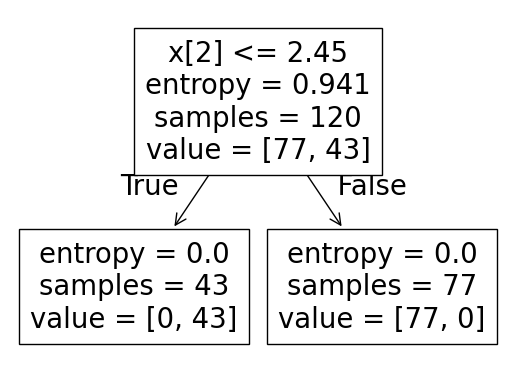

In [15]:
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix for Entropy")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
plot_tree(ig_tree)
plt.show()